# 뇌졸중(Stroke) 예측 프로젝트 — 최종 통합 분석

이 노트북은 데사프 프로젝트의 EDA(`stroke_eda.ipynb`)와 최종 전처리/모델링(`programing_project(subgroup수정).ipynb`)을 하나로 통합한 최종 분석본입니다.


# 1. 탐색적 데이터 분석 (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

In [39]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data.csv") 

# id 열은 필요 없으니까 삭제
data = data.drop(columns="id",axis=1)

# 불균형 데이터

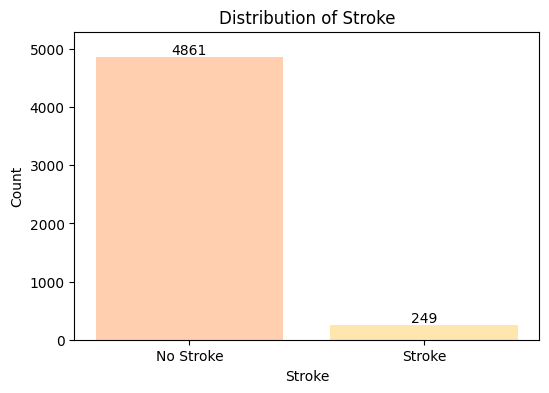

In [40]:
# 0과 1의 개수 계산
num_zeros = data['stroke'].value_counts()[0]
num_ones = data['stroke'].value_counts()[1]

# 그림 크기 조정
plt.figure(figsize=(6, 4))

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(['No Stroke', 'Stroke'], [num_zeros, num_ones], color = colors)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke')
plt.ylim(0, 5300)  # y 범위 설정 (start, end)

# 개수를 그래프에 텍스트로 표시
plt.text(0, num_zeros, f'{num_zeros}', ha='center', va='bottom')
plt.text(1, num_ones, f'{num_ones}', ha='center', va='bottom')

plt.savefig('stroke_count.png')

plt.show()

# 결측치

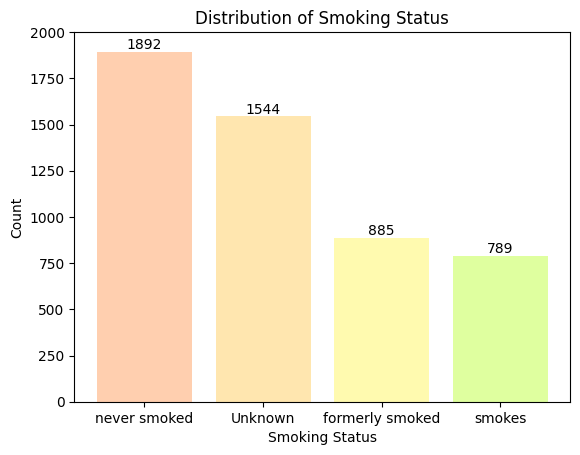

In [41]:
# 흡연 여부 칼럼 값의 개수 계산
value_counts = data['smoking_status'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Distribution of Smoking Status')
plt.ylim(0, 2000)  # y 범위 설정 (start, end)
# 개수를 그래프에 텍스트로 표시
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()

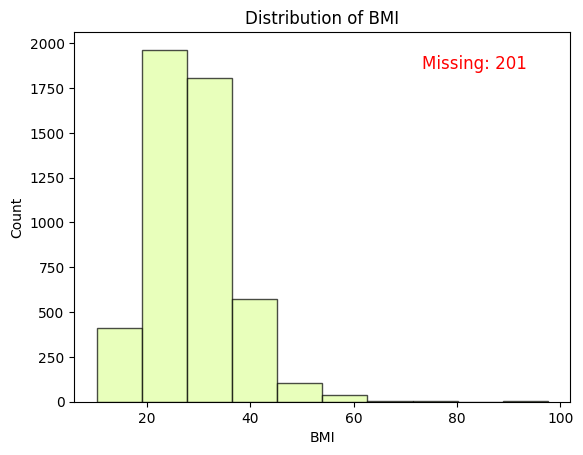

In [42]:
# 결측치 확인
missing_values = data['bmi'].isnull()

# 결측치 포함한 히스토그램
plt.hist(data['bmi'], bins=10, alpha=0.7, edgecolor='black', color = '#DFFF9F')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('Distribution of BMI')

# 결측치를 텍스트로 표시
missing_count = np.sum(missing_values)
plt.text(0.7, 0.9, f'Missing: {missing_count}', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.show()

# 이상치

성별

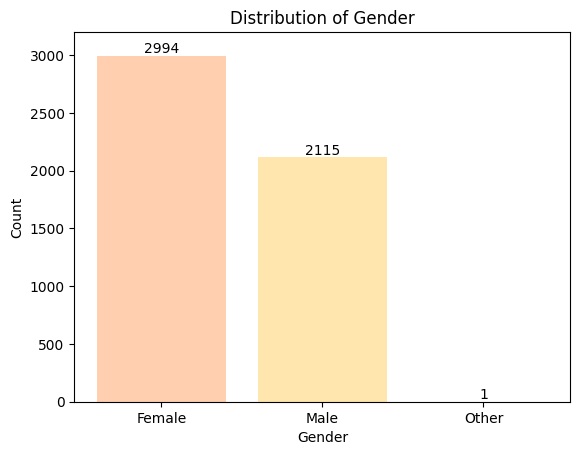

In [43]:
# 성별 칼럼 값의 개수 계산
value_counts = data['gender'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.ylim(0, 3200)
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()


bmi이상치 #결측치 제거하지않은 원본데이터

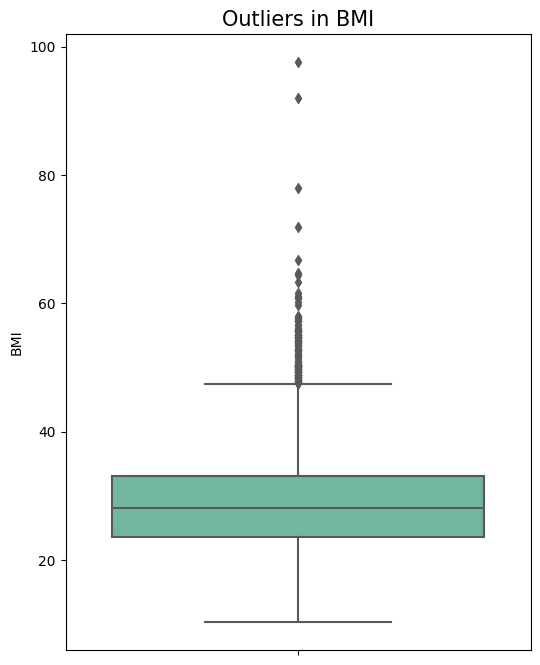

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()

plt.figure(figsize=(6, 8))  # 그래프의 크기를 조정합니다.

sns.boxplot(y='bmi', data=df)

plt.title('Outliers in BMI', fontsize=15)
plt.ylabel('BMI')
plt.show()

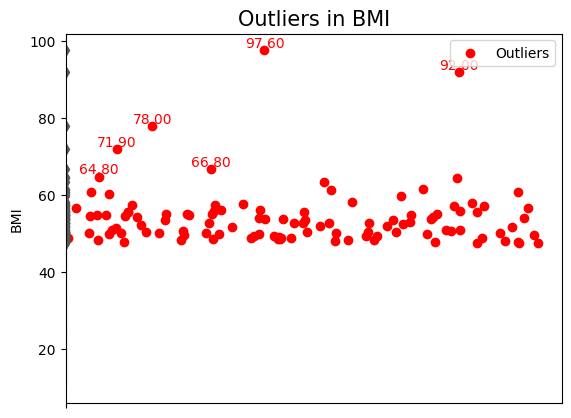

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()

# 이상치를 확인하고 싶은 칼럼과 데이터프레임을 사용하여 이상치 시각화
sns.boxplot(y='bmi', data=df)

plt.title('Outliers in BMI', fontsize=15)
plt.ylabel('BMI')

# 이상치 데이터를 따로 표시
outliers = df[df['bmi'] > df['bmi'].quantile(0.75) + 1.5 * (df['bmi'].quantile(0.75) - df['bmi'].quantile(0.25))]
plt.scatter(x=outliers.index, y=outliers['bmi'], color='red', label='Outliers')

# 이상치로 판단된 상위 6개 값 표시
top_outliers = outliers.nlargest(6, 'bmi')
for i, outlier in top_outliers.iterrows():
    plt.text(i, outlier['bmi'], f'{outlier["bmi"]:.2f}', ha='center', va='bottom', color='red')

plt.legend()
plt.show()


In [46]:
# 이상치로 판단된 상위 6개 행 출력
outliers = df[df['bmi'] > df['bmi'].quantile(0.75) + 1.5 * (df['bmi'].quantile(0.75) - df['bmi'].quantile(0.25))]
top_outliers = outliers.nlargest(6, 'bmi')

print(top_outliers)

      gender   age  hypertension  heart_disease ever_married      work_type  \
2128    Male  17.0             1              0           No        Private   
4209    Male  38.0             1              0          Yes        Private   
928   Female  23.0             1              0           No        Private   
544     Male  42.0             0              0          Yes        Private   
1559  Female  53.0             0              0          Yes        Private   
358     Male  52.0             0              0          Yes  Self-employed   

     Residence_type  avg_glucose_level   bmi smoking_status  stroke  
2128          Rural              61.67  97.6        Unknown       0  
4209          Rural              56.90  92.0   never smoked       0  
928           Urban              70.03  78.0         smokes       0  
544           Rural             210.48  71.9   never smoked       0  
1559          Rural              72.63  66.8        Unknown       0  
358           Urban       

# 전체적인 분포

나이부분

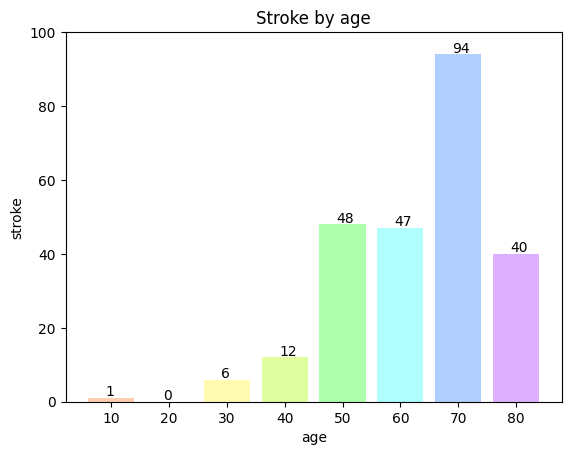

In [ ]:
def age_categorize(age):
  age = (age// 10) *10
  return age

age_category = data.age.apply(age_categorize)
age_category

data_age = data.copy()
data_age['age_category'] = age_category
data_age

# 리스트 만들기
stroke = []
age = []

for i in range(1,9):
  age.append(i*10)
  a = data_age.loc[data_age['age_category'] == i * 10.0]
  stroke.append(a['stroke'].sum())

xs = [i for i, _ in enumerate(age)]
colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F', '#AFFFAF', '#AFFFFF', '#AFCFFF', '#DFAFFF']

plt.bar(xs, stroke,color=colors)  # 해당 인덱스에 일치하는 값을 가진, 바 형태 그래프 생성
plt.xlabel("age")
plt.ylabel("stroke")
plt.xticks([i for i, _ in enumerate(age)], age)  # x 눈금 및 레이블 설정 
plt.title("Stroke by age")
plt.ylim(0, 100)  # y 범위 설정 (start, end)

for index, value in enumerate(stroke):
  plt.text(index - 0.1, value + 0.5, str(value))  # x 좌표, y 좌표, text
plt.show()

성별부분 # 이상치 제거한것

<ipython-input-10-a1a2daf15ce8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['stroke'] = filtered_df['stroke'].map({0: 'no stroke', 1: 'stroke'})
<ipython-input-10-a1a2daf15ce8>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


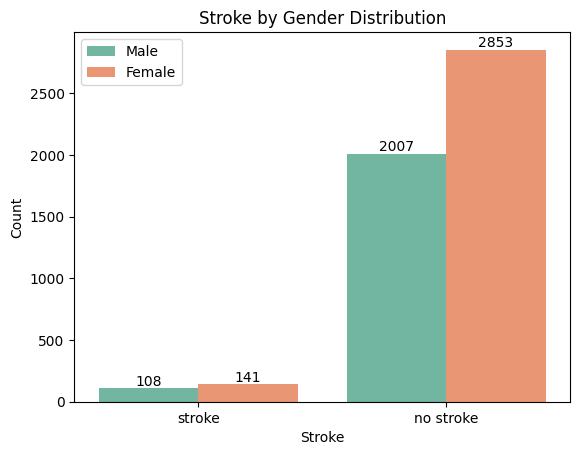

In [ ]:
from matplotlib import cm

# "other" 값을 제외한 데이터프레임 생성

filtered_df = data[data['gender'] != 'Other']

# 뇌졸중 여부를 "no stroke"와 "stroke"로 변환
filtered_df['stroke'] = filtered_df['stroke'].map({0: 'no stroke', 1: 'stroke'})

# 성별별 뇌졸중 여부 시각화
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)
ax = sns.countplot(x='stroke', hue='gender', data=filtered_df)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Gender Distribution')

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례에 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label != 'other']
ax.legend(handles, labels)

plt.show()


고혈압

<ipython-input-11-2d5d4392a627>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


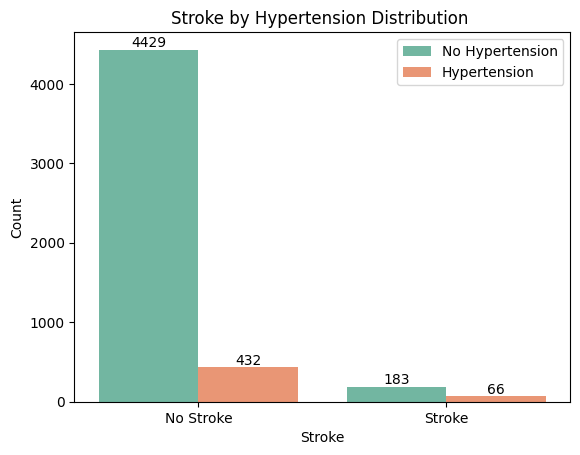

In [ ]:
from matplotlib import cm

# ColorBrewer의 Set2 컬러 맵 사용 (8개의 색상)
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)

# 뇌졸중 여부에 따라 고혈압 여부를 시각화
ax = sns.countplot(x='stroke', hue='hypertension', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Hypertension Distribution ')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['No Hypertension', 'Hypertension']
ax.legend(handles, labels)

plt.show()



심장병

<ipython-input-47-5ac8985f4cdb>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


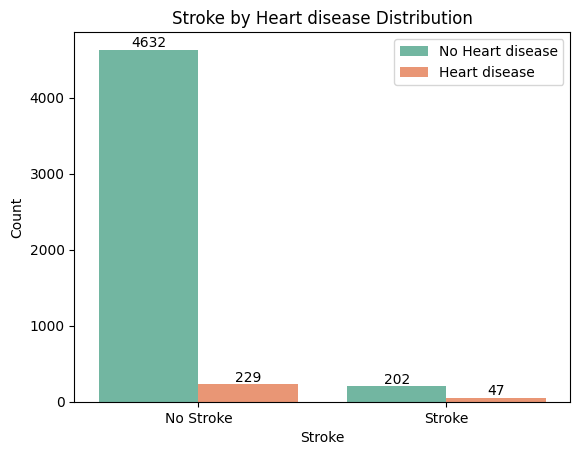

In [47]:
from matplotlib import cm

# ColorBrewer의 Set2 컬러 맵 사용 (8개의 색상)
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)

# 뇌졸중 여부에 따라 고혈압 여부를 시각화
ax = sns.countplot(x='stroke', hue='heart_disease', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Heart disease Distribution')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['No Heart disease', 'Heart disease']
ax.legend(handles, labels)

plt.show()

결혼

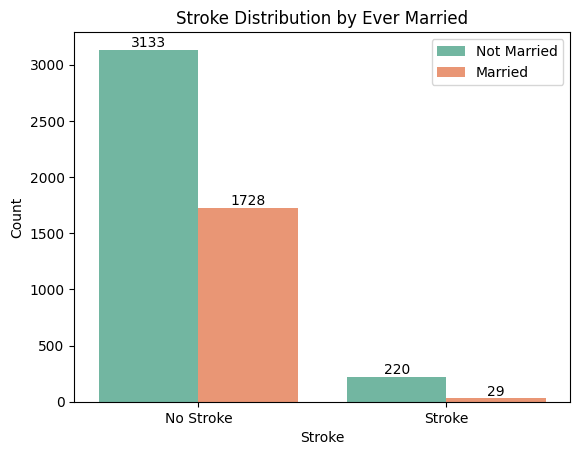

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='ever_married', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Ever Married')

# 각 막대에 정수형 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['Not Married', 'Married']
ax.legend(handles, labels)

plt.show()


직업

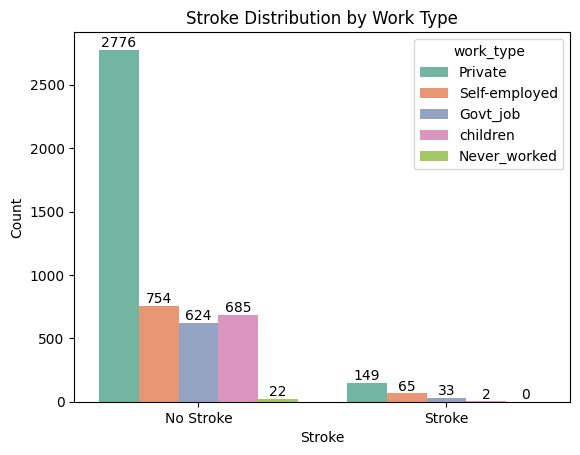

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='work_type', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Work Type')

# 각 막대에 정수형 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


거주지역

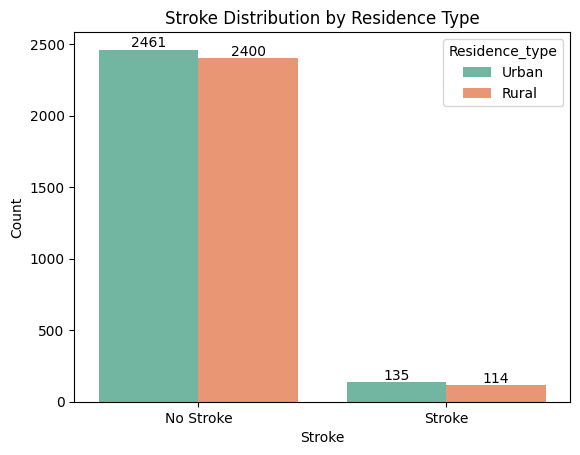

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='Residence_type', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Residence Type')

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


흡연여부

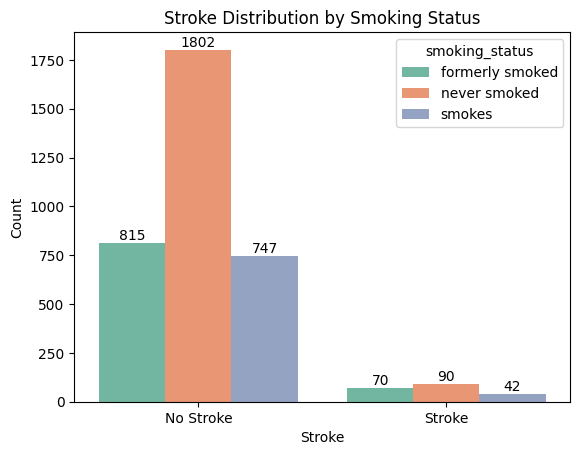

In [ ]:
# 'Unknown' 제외한 데이터 필터링
filtered_df = data[data['smoking_status'] != 'Unknown']

# 시각화
ax = sns.countplot(x='stroke', hue='smoking_status', data=filtered_df)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Smoking Status')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

plt.show()

혈당수치

<ipython-input-17-42830e3e764b>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 0]["avg_glucose_level"], color='green', label='No Stroke') # No Stroke - green
<ipython-input-17-42830e3e764b>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 1]["avg_g

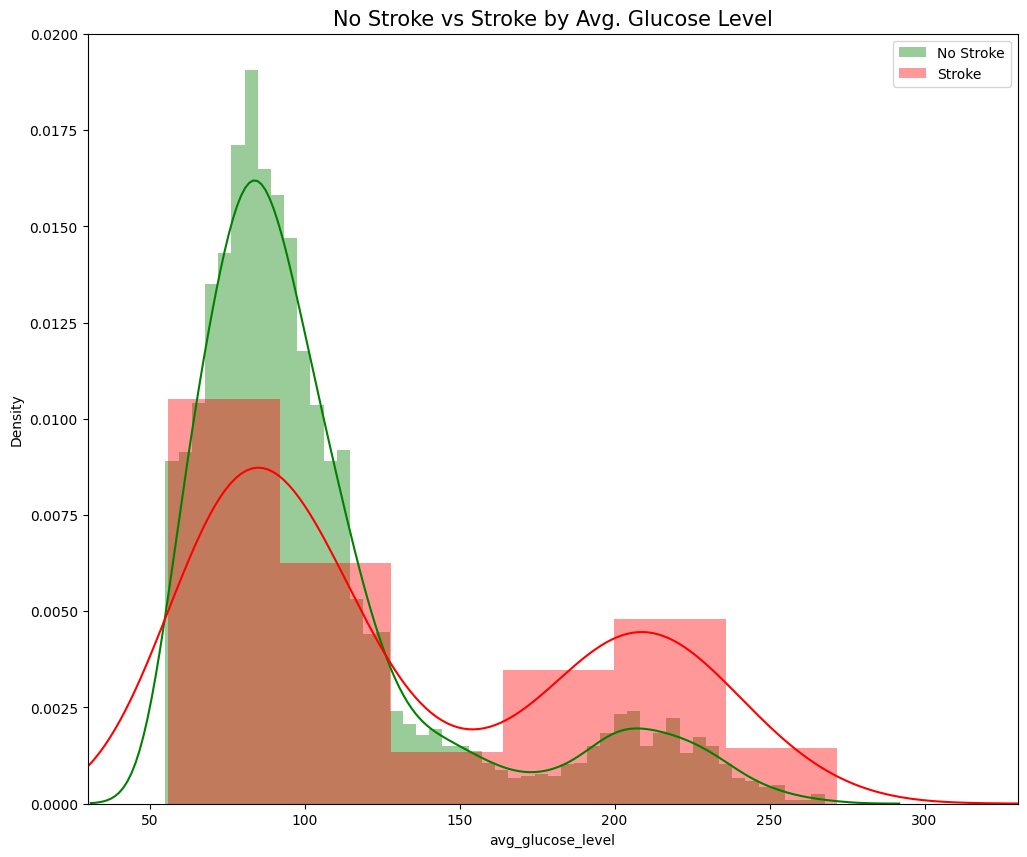

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.distplot(data[data['stroke'] == 0]["avg_glucose_level"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data[data['stroke'] == 1]["avg_glucose_level"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by Avg. Glucose Level', fontsize=15)
plt.xlim([30,330])

# 범례 추가
plt.legend()

plt.show()


bmi

<ipython-input-18-1ebef17fa037>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 0]["bmi"], color='green', label='No Stroke') # No Stroke - green
<ipython-input-18-1ebef17fa037>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 1]["bmi"], color='red',

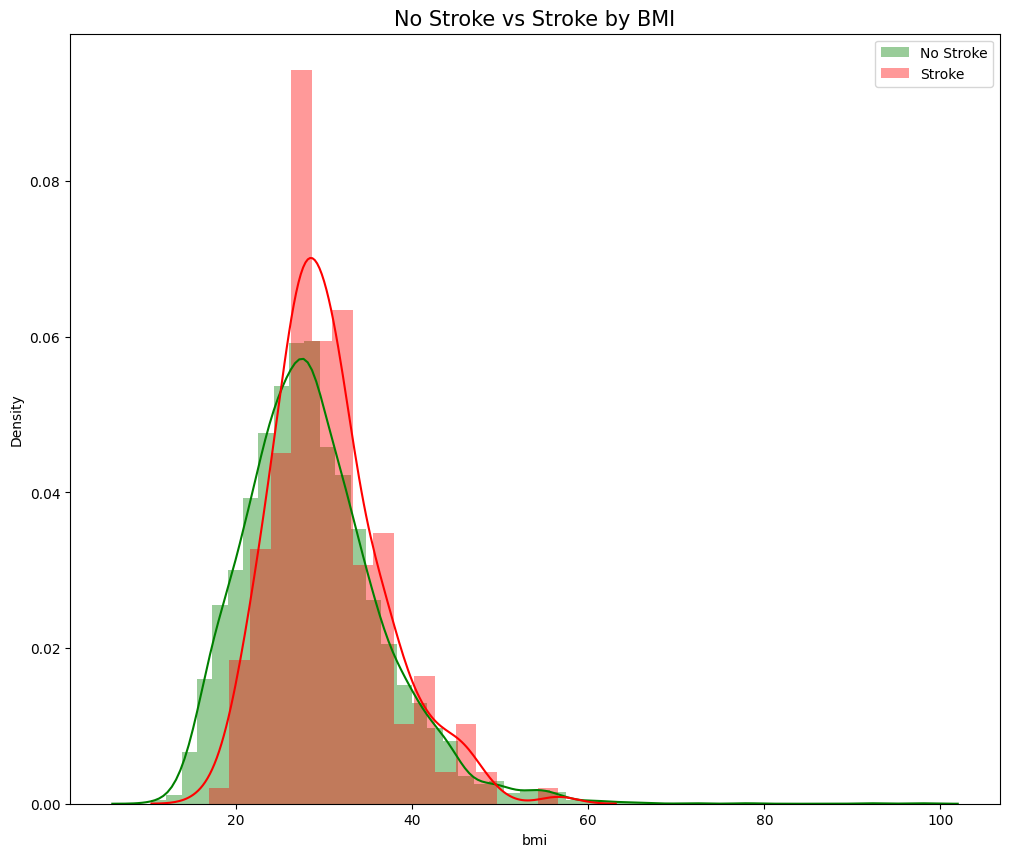

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.distplot(data[data['stroke'] == 0]["bmi"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data[data['stroke'] == 1]["bmi"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by BMI', fontsize=15)

# 범례 추가
plt.legend()

plt.show()

# 2. 전처리 및 모델링 (최종)

In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import RFECV

In [250]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from imblearn.under_sampling import NearMiss
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
!pip install eli5
import eli5
from eli5.sklearn import PermutationImportance

from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from collections import defaultdict

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [251]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [252]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv") # 데이터 불러오기

In [253]:
data = pd.read_csv("stroke final data.csv")

In [254]:
data_age_70 = pd.read_csv("data_age_70.csv")
age70_index = data_age_70["index"]

In [255]:
column_unique = ['gender', 'hypertension', 'heart_disease',  # unique 값을 보고싶은 열만 변수에 저장
                 'ever_married','work_type', 'Residence_type', 
                 'smoking_status', 'stroke']

In [256]:
for i in column_unique: # 각 행별로 어떤 값들이 있는지 
    a = df[i].unique()
    print(a)

['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [257]:
df.info() # 결측값 확인 / age 실수인것 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# 전처리

## 시각화

In [258]:
data_original = pd.read_csv("healthcare-dataset-stroke-data.csv")
# id 열은 필요 없으니까 삭제
data_original = data_original.drop(columns="id",axis=1)

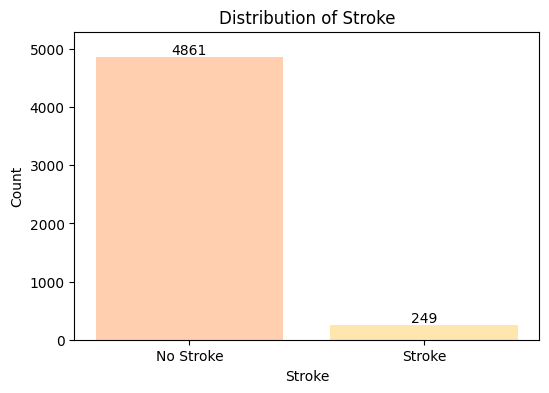

In [259]:
# 0과 1의 개수 계산
num_zeros = data_original['stroke'].value_counts()[0]
num_ones = data_original['stroke'].value_counts()[1]

# 그림 크기 조정
plt.figure(figsize=(6, 4))

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(['No Stroke', 'Stroke'], [num_zeros, num_ones], color = colors)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke')
plt.ylim(0, 5300)  # y 범위 설정 (start, end)

# 개수를 그래프에 텍스트로 표시
plt.text(0, num_zeros, f'{num_zeros}', ha='center', va='bottom')
plt.text(1, num_ones, f'{num_ones}', ha='center', va='bottom')


plt.show()

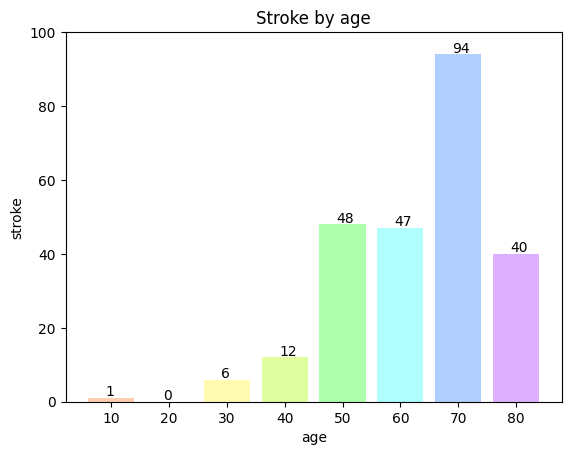

In [260]:
def age_categorize(age):
  age = (age// 10) *10
  return age

age_category = data_original.age.apply(age_categorize)
age_category

data_original_age = data_original.copy()
data_original_age['age_category'] = age_category
data_original_age

# 리스트 만들기
stroke = []
age = []

for i in range(1,9):
  age.append(i*10)
  a = data_original_age.loc[data_original_age['age_category'] == i * 10.0]
  stroke.append(a['stroke'].sum())

xs = [i for i, _ in enumerate(age)]
colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F', '#AFFFAF', '#AFFFFF', '#AFCFFF', '#DFAFFF']

plt.bar(xs, stroke,color=colors)  # 해당 인덱스에 일치하는 값을 가진, 바 형태 그래프 생성
plt.xlabel("age")
plt.ylabel("stroke")
plt.xticks([i for i, _ in enumerate(age)], age)  # x 눈금 및 레이블 설정 
plt.title("Stroke by age")
plt.ylim(0, 100)  # y 범위 설정 (start, end)

for index, value in enumerate(stroke):
  plt.text(index - 0.1, value + 0.5, str(value))  # x 좌표, y 좌표, text
plt.show()

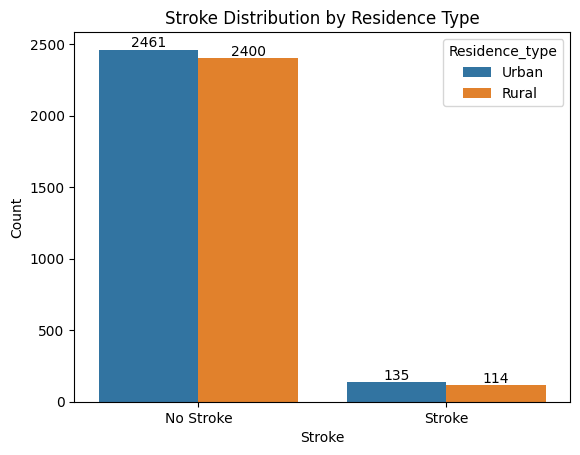

In [261]:
# 시각화
ax = sns.countplot(x='stroke', hue='Residence_type', data=data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Residence Type')

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


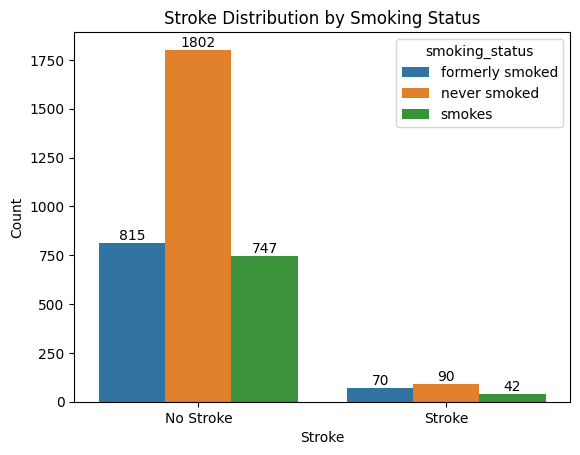

In [262]:
# 'Unknown' 제외한 데이터 필터링
data_original = data_original[data_original['smoking_status'] != 'Unknown']

# 시각화
ax = sns.countplot(x='stroke', hue='smoking_status', data= data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Smoking Status')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

plt.show()

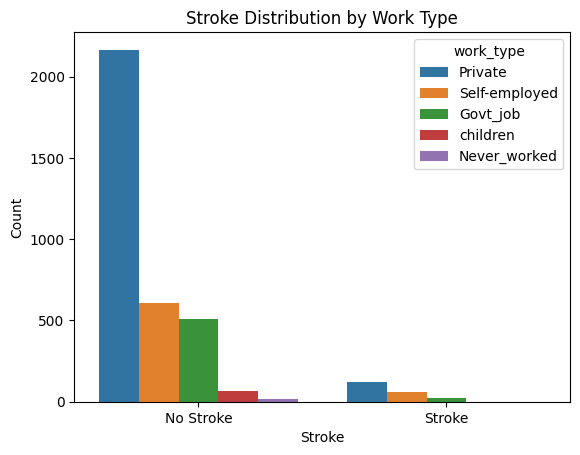

In [263]:
# 시각화
ax = sns.countplot(x='stroke', hue='work_type', data =data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Work Type')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


- 혈당수준에 따른 분포

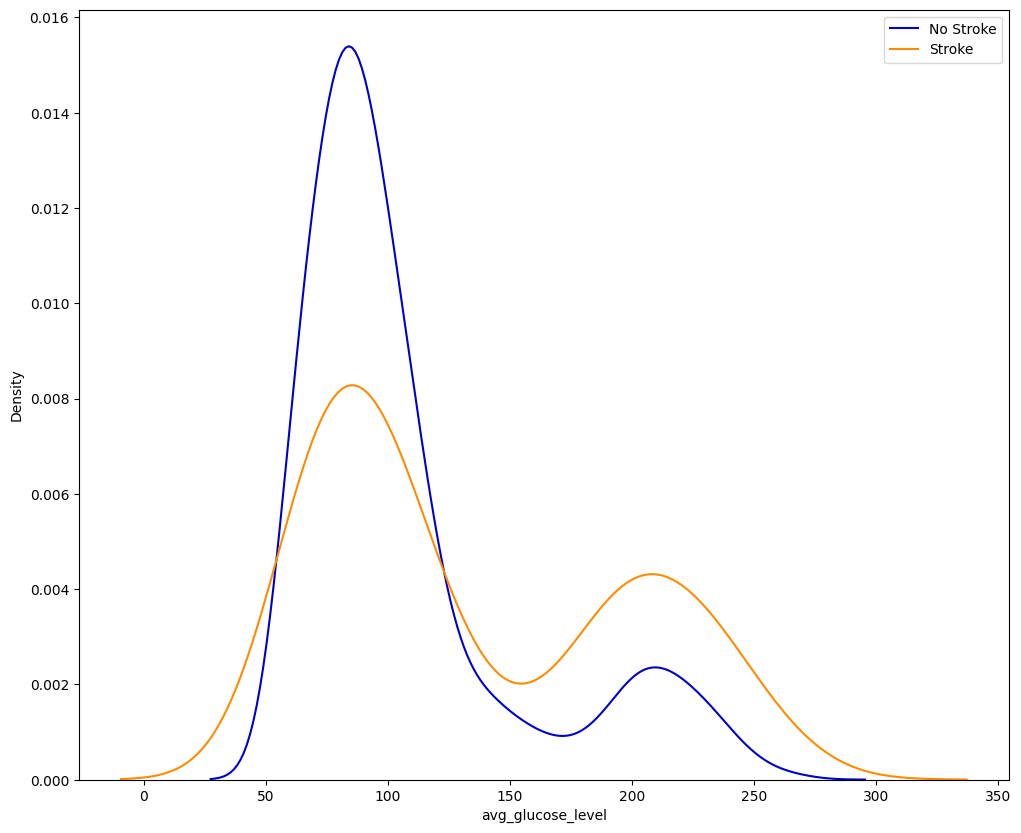

In [264]:
plt.figure(figsize=(12,10))

sns.distplot(data_original[data_original['stroke'] == 0]["avg_glucose_level"], color='mediumblue', label='No Stroke', hist = False) # No Stroke - blue

sns.distplot(data_original[data_original['stroke'] == 1]["avg_glucose_level"], color='darkorange', label='Stroke', hist = False) # Stroke - orange

plt.legend()

plt.show()

- bmi 수준에 따른 분포

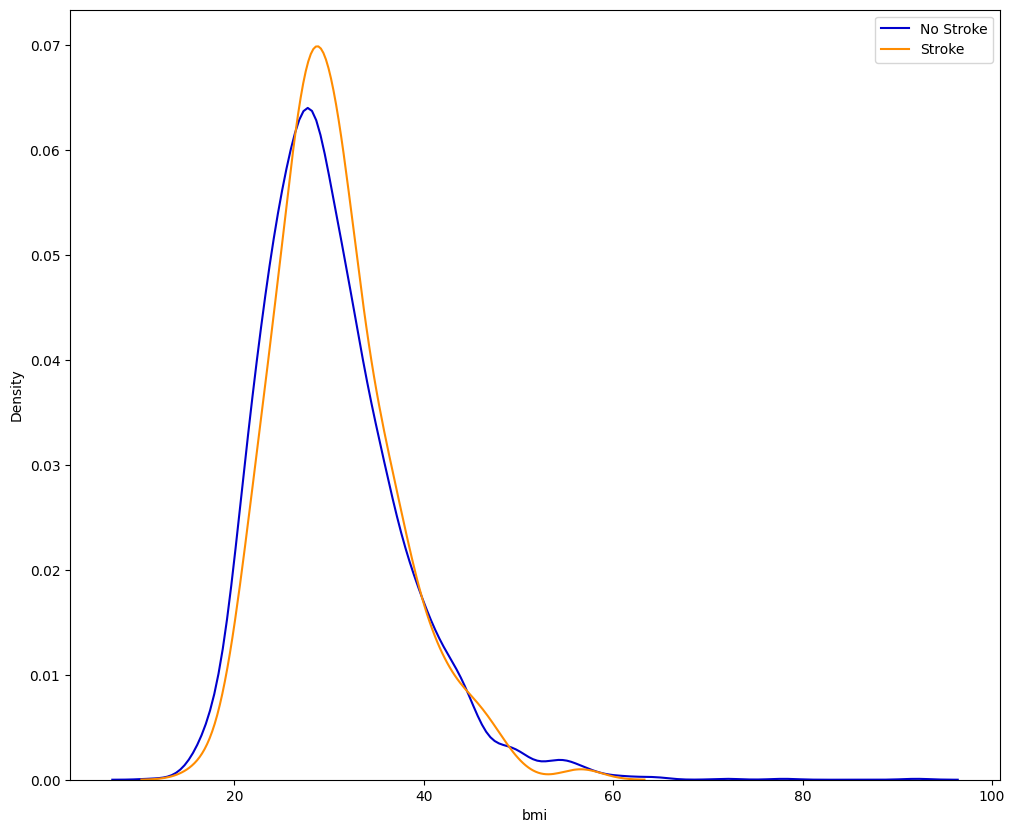

In [265]:
plt.figure(figsize=(12,10))

sns.distplot(data_original[data_original['stroke'] == 0]["bmi"], color='mediumblue', label='No Stroke', hist = False) # No Stroke - blue

sns.distplot(data_original[data_original['stroke'] == 1]["bmi"], color='darkorange', label='Stroke', hist = False) # Stroke - orange

# 범례 추가
plt.legend()

plt.show()

## 이상치 
- gender

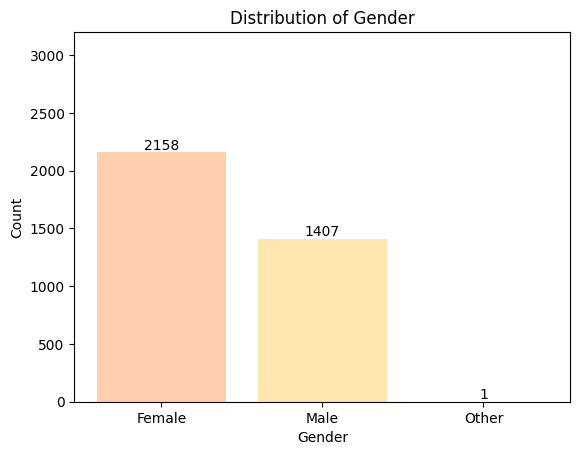

In [266]:
# 성별 칼럼 값의 개수 계산
value_counts = data_original['gender'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.ylim(0, 3200)
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()


In [267]:
df["gender"].value_counts() #  한 개밖에 없어서 제거 결정

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [268]:
df.loc[df["gender"] == "Other"].index

Int64Index([3116], dtype='int64')

In [269]:
df = df.drop(data.loc[data["gender"] == "Other"].index, axis=0).copy() # Other 행 삭제

In [270]:
df["gender"].value_counts() # 지워졌나 확인

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

## 결측값
- 흡연 컬럼의 unkown
- bmi 결측값

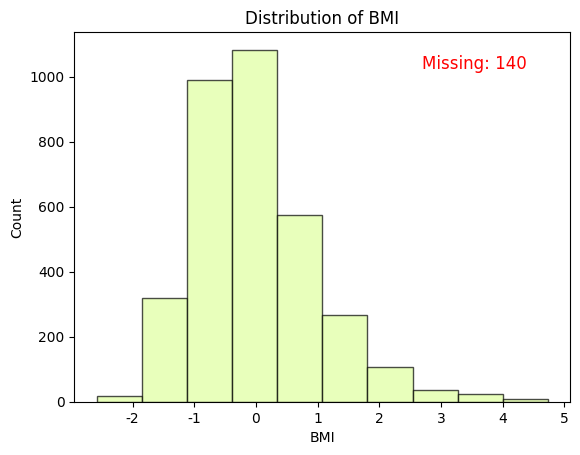

In [271]:
# 결측치 확인
missing_values = data_original['bmi'].isnull()

# 결측치 포함한 히스토그램
plt.hist(data['bmi'], bins=10, alpha=0.7, edgecolor='black', color = '#DFFF9F')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('Distribution of BMI')

# 결측치를 텍스트로 표시
missing_count = np.sum(missing_values)
plt.text(0.7, 0.9, f'Missing: {missing_count}', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.show()

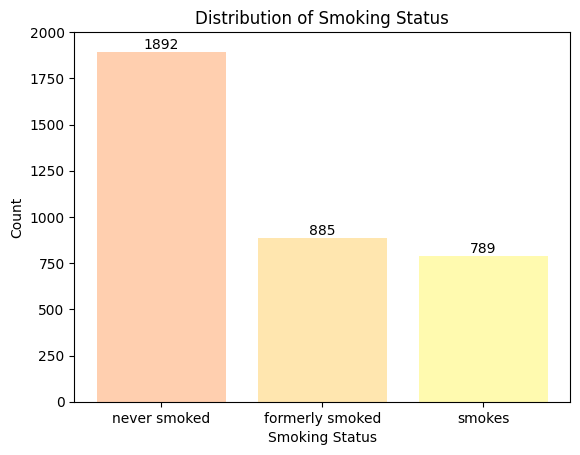

In [272]:
# 흡연 여부 칼럼 값의 개수 계산
value_counts = data_original['smoking_status'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Distribution of Smoking Status')
plt.ylim(0, 2000)  # y 범위 설정 (start, end)
# 개수를 그래프에 텍스트로 표시
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()

- 결측값 비율이 43%임

In [273]:
df["smoking_status"].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [274]:
1544/(1892+884+789) * 100 # 결측값 비율 43%

43.30995792426368

In [275]:
df = df.drop(df.loc[df["smoking_status"]=="Unknown"].index, axis = 0).copy() # Unkown이 있는 행 모두 삭제

In [276]:
df["smoking_status"].value_counts()

never smoked       1892
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [277]:
df = df.loc[~df["bmi"].isna()] # bmi가 결측값이 아닌 행들만 가져옴

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3426 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3426 non-null   int64  
 1   gender             3426 non-null   object 
 2   age                3426 non-null   float64
 3   hypertension       3426 non-null   int64  
 4   heart_disease      3426 non-null   int64  
 5   ever_married       3426 non-null   object 
 6   work_type          3426 non-null   object 
 7   Residence_type     3426 non-null   object 
 8   avg_glucose_level  3426 non-null   float64
 9   bmi                3426 non-null   float64
 10  smoking_status     3426 non-null   object 
 11  stroke             3426 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 348.0+ KB


## 자료형 변경
- age 실수 -> 정수

In [279]:
df = df.astype({"age":int})

In [280]:
df["age"].dtype

dtype('int64')

## 이진화 / 더미변수
- gender
- ever_married
- Residence_type
- smoking_status
- work_type

In [281]:
df['gender'] = df['gender'].apply(lambda x: 1 if x=='Male' else 0) # 이진화 
df['ever_married'] = df['ever_married'].apply(lambda x: 1 if x=='Yes' else 0)
df['Residence_type'] = df['Residence_type'].apply(lambda x: 1 if x=='Urban' else 0)

In [282]:
# 더미변수 만들기
df = pd.get_dummies(df, columns = ['work_type','smoking_status']).copy()


In [283]:
df.columns = df.columns.str.replace('work_type_', '') # 더미변수로 바꿀 때 고정적으로 붙는 접두어 삭제
df.columns = df.columns.str.replace('smoking_status_', '')


In [284]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes
0,9046,1,67,0,1,1,1,228.69,36.6,1,0,0,1,0,0,1,0,0
2,31112,1,80,0,1,1,0,105.92,32.5,1,0,0,1,0,0,0,1,0
3,60182,0,49,0,0,1,1,171.23,34.4,1,0,0,1,0,0,0,0,1
4,1665,0,79,1,0,1,0,174.12,24.0,1,0,0,0,1,0,0,1,0
5,56669,1,81,0,0,1,1,186.21,29.0,1,0,0,1,0,0,1,0,0


In [285]:
# id 열은 필요 없으니까 삭제
df = df.drop(columns="id",axis=1)

In [286]:
# stroke 맨뒤로 보내줌
# col2 열의 위치를 가져옴
col2_idx = df.columns.get_loc('stroke')

# 열 순서를 변경한 새로운 데이터프레임 생성
new_order = list(range(len(df.columns)))
new_order.pop(col2_idx)
new_order.append(col2_idx)
df = df.reindex(columns=df.columns[new_order])

## 표준화/정규화

- 정규화 : 데이터 셋 최솟값이 0이 되고, 데이터셋의 최대값 1 분포에 영향x

In [287]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()

# 열들을 표준화
df[["age","avg_glucose_level","bmi"]] = scaler.fit_transform(df[["age","avg_glucose_level","bmi"]])
df.tail()


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
5100,1,1.769588,1,0,1,0,-0.762149,-0.272800,0,0,0,1,0,0,1,0,0
5102,0,0.443222,0,0,1,0,-0.637192,-1.177542,0,0,1,0,0,0,1,0,0
5106,0,1.716533,0,0,1,1,0.353864,1.331062,0,0,0,1,0,0,1,0,0
5107,0,-0.723981,0,0,1,0,-0.531105,0.042489,0,0,0,1,0,0,1,0,0
5108,1,0.124894,0,0,1,0,1.215352,-0.642922,0,0,1,0,0,1,0,0,0


- 이상치 추가처리(bmi)

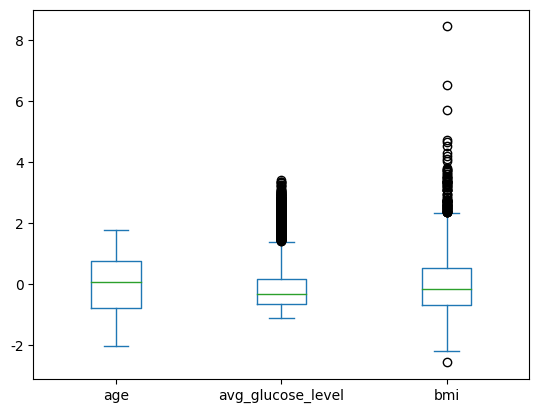

In [288]:
df[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

- bmi 값에서 극단적인 값은 제거
- -2.5 보다 작은 값의 bmi는 어떻게 할까?

In [289]:
# bmi 값이 5보다 큰 3개 행 제거 / # 544 928 4209/ 2187
df = df[df["bmi"]<5]


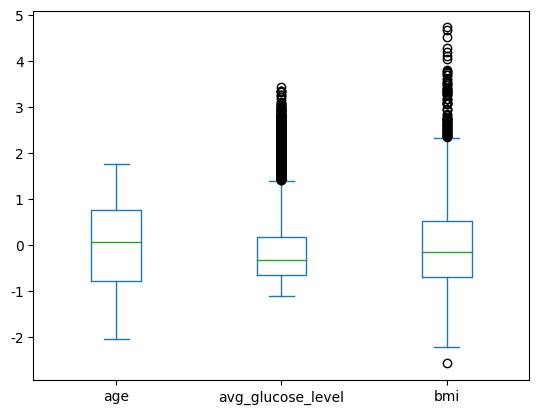

In [290]:
df[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

## feature selection : 상관관계 분석

* 연속형 변수

In [291]:
df_continuous = df[["age","bmi","avg_glucose_level"]]

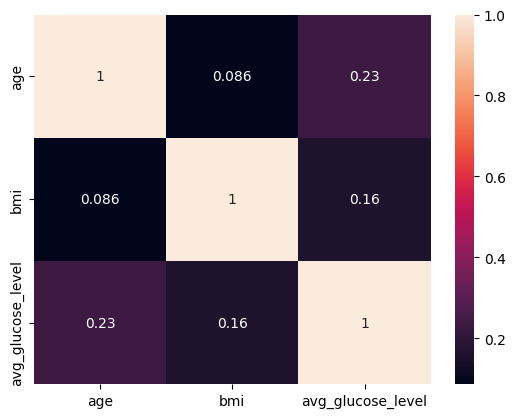

In [292]:
corr_matrix = df_continuous.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

* 범주형 변수

In [293]:
df_categorical = df.drop("stroke",axis=1).copy()

In [294]:
df_categorical = df_categorical.drop(columns=["age","bmi","avg_glucose_level"],axis=1).copy()

In [295]:
from scipy.stats import chi2_contingency
import numpy as np




def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) # Cross table building
  stat = chi2_contingency(crosstab)[0] # Keeping of the test statistic of the Chi2 test
  obs = np.sum(crosstab) # Number of observations
  mini = min(crosstab.shape)-1 # Take the minimum value between the columns and the rows of the cross table
  return (stat/(obs*mini))

In [296]:
rows= []

for var1 in df_categorical:
  col = []
  for var2 in df_categorical :
    cramers =cramers_V(df_categorical[var1], df_categorical[var2]) # Cramer's V test
    col.append(round(cramers,2)) # Keeping of the rounded value of the Cramer's V  
  rows.append(col)
  
cramers_results = np.array(rows)
df_selection = pd.DataFrame(cramers_results, columns = df_categorical.columns, index =df_categorical.columns)
df_selection

,gender,hypertension,heart_disease,ever_married,Residence_type,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes
gender,1.00,0.00,0.01,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00
hypertension,0.00,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
heart_disease,0.01,0.01,0.99,0.01,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00
ever_married,0.00,0.01,0.01,1.00,0.0,0.00,0.01,0.00,0.02,0.06,0.01,0.01,0.00
Residence_type,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Govt_job,0.00,0.00,0.00,0.00,0.0,1.00,0.00,0.32,0.04,0.00,0.00,0.00,0.00
Never_worked,0.00,0.00,0.00,0.01,0.0,0.00,0.93,0.01,0.00,0.00,0.00,0.00,0.00
Private,0.00,0.00,0.00,0.00,0.0,0.32,0.01,1.00,0.40,0.04,0.00,0.00,0.00
Self-employed,0.00,0.01,0.00,0.02,0.0,0.04,0.00,0.40,1.00,0.00,0.01,0.00,0.00
children,0.00,0.00,0.00,0.06,0.0,0.00,0.00,0.04,0.00,0.99,0.00,0.00,0.00


## 오버샘플링 후 랜덤포레스트

### SMOTE

In [297]:
x = df.drop("stroke",axis = 1) #독립변수
y = df["stroke"] # 종속변수

In [298]:
# train 과 test데이터를 미리나눠 test데이터의 독립성을 유지할 수 있게함
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [299]:
# 오버 샘플링을 통해 불균형 데이터 처리
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x_train,y_train)  # train df에 대해서만 오버샘플링 진행함

# 분포 변화
print("before SMOTE :\n", y.value_counts()) # 기존 뇌졸중 비율 분포
print("\nafter SMOTE :\n", y_resampled_smote.value_counts()) # 불균형 처리 후 뇌졸중 비율 분포

before SMOTE :
 0    3243
1     180
Name: stroke, dtype: int64

after SMOTE :
 0    2275
1    2275
Name: stroke, dtype: int64


In [300]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote,test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.94 precision :0.92 recall :0.96
MAE:0.06 
F1-score :0.94 


## 언더샘플링 후 랜덤포레스트
- RandomUnderSampler
- NearMiss
- TomekLinks
- EditedNearestNeighbours
- OneSidedSelection

### RandomUnderSampler
- 랜덤으로 데이터 지움

In [301]:
y.value_counts()

0    3243
1     180
Name: stroke, dtype: int64

In [302]:
from imblearn.under_sampling import RandomUnderSampler


# 언더샘플링 수행
rus = RandomUnderSampler(random_state=42)
x_resampled_rus, y_resampled_rus = rus.fit_resample(x, y)

y_count = y_resampled_rus.value_counts()

# 언더샘플링된 데이터 확인
print(y_count)

0    180
1    180
Name: stroke, dtype: int64


In [303]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_rus, y_resampled_rus, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

# 예측값과 실제값을 넣어서 ROC 곡선 및 ROC AUC 점수 계산
y_pred_proba = xgb.predict_proba(x_test)[:,1]

fpr_rus, tpr_rus, thresholds = roc_curve(y_test, y_pred_proba)
auc_rus = roc_auc_score(y_test, y_pred_proba)

accuracy :0.77 precision :0.73 recall :0.84
MAE:0.23 
F1-score :0.78 


In [304]:
# k-fold 교차검증 수행
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.70 (+/- 0.03)
Precision: 0.70 (+/- 0.05)
Recall: 0.71 (+/- 0.06)
F1 score: 0.70 (+/- 0.03)


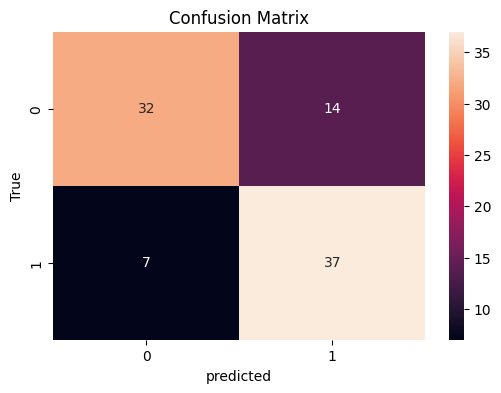

In [305]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### TomekLinks
- 두 범주중에 가까운 것들끼리 link 된 후 다수 범주 제거 -> 분류경계에서 데이터가 제거됨

In [306]:
from imblearn.under_sampling import TomekLinks

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_tl, y_resampled_tl = TomekLinks().fit_resample(x, y)

# 데이터 불균형 해소 효과가 적음
y_resampled_tl.value_counts()

0    3156
1     180
Name: stroke, dtype: int64

In [307]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_tl, y_resampled_tl, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

# 예측값과 실제값을 넣어서 ROC 곡선 및 ROC AUC 점수 계산
y_pred_proba = xgb.predict_proba(x_test)[:,1]

fpr_tm, tpr_tm, thresholds = roc_curve(y_test, y_pred_proba)
auc_tm = roc_auc_score(y_test, y_pred_proba)

accuracy :0.92 precision :0.21 recall :0.05
MAE:0.08 
F1-score :0.09 


In [308]:
# k-fold 교차검증 수행

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.94 (+/- 0.01)
Precision: 0.25 (+/- 0.21)
Recall: 0.08 (+/- 0.07)
F1 score: 0.12 (+/- 0.10)


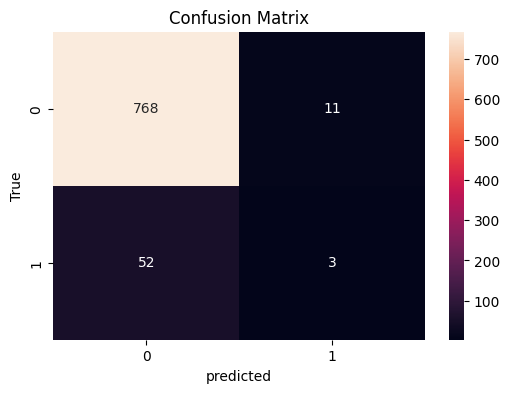

In [309]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### NearMiss

Nearmiss-1 : Majority class examples with minimum average distance to three closest minority class examples.

In [310]:
from imblearn.under_sampling import NearMiss

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns1, y_resampled_ns1 = NearMiss(version=1).fit_resample(x, y)

y_resampled_ns1.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [311]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

# 예측값과 실제값을 넣어서 ROC 곡선 및 ROC AUC 점수 계산
y_pred_proba = xgb.predict_proba(x_test)[:,1]

fpr_ns1, tpr_ns1, thresholds = roc_curve(y_test, y_pred_proba)
auc_ns1 = roc_auc_score(y_test, y_pred_proba)

accuracy :0.76 precision :0.75 recall :0.75
MAE:0.24 
F1-score :0.75 


In [312]:
# k-fold 교차검증 수행

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.75 (+/- 0.04)
Precision: 0.76 (+/- 0.06)
Recall: 0.76 (+/- 0.06)
F1 score: 0.76 (+/- 0.03)


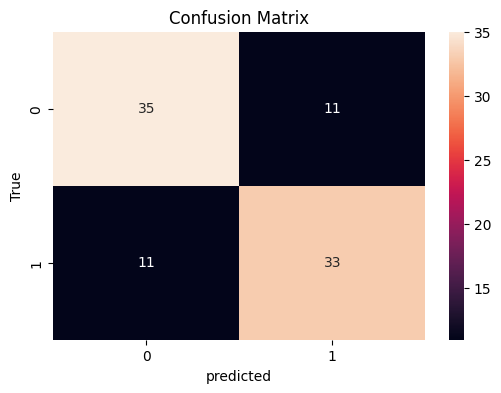

In [313]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

NearMiss-2: Majority class examples with minimum average distance to three furthest minority class examples.
- 성능 제일 좋음

- MAE 값이 0에 가까움
- 정확도 정밀도 재현율 모두 높음
- F1이 높음
- FN 수가 가장 적음

In [314]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)

y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [315]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

# 예측값과 실제값을 넣어서 ROC 곡선 및 ROC AUC 점수 계산
y_pred_proba = xgb.predict_proba(x_test)[:,1]

fpr_ns2, tpr_ns2, thresholds = roc_curve(y_test, y_pred_proba)
auc_ns2 = roc_auc_score(y_test, y_pred_proba)

accuracy :0.88 precision :0.92 recall :0.82
MAE:0.12 
F1-score :0.87 


In [316]:
# k-fold 교차검증 수행

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.87 (+/- 0.03)
Precision: 0.90 (+/- 0.06)
Recall: 0.85 (+/- 0.03)
F1 score: 0.87 (+/- 0.03)


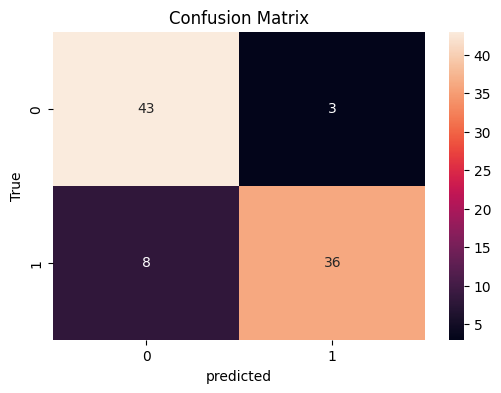

In [317]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

NearMiss-3: Majority class examples with minimum distance to each minority class example.

In [318]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns3, y_resampled_ns3 = NearMiss(version=3).fit_resample(x, y)

y_resampled_ns3.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [319]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns3, y_resampled_ns3, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

# 예측값과 실제값을 넣어서 ROC 곡선 및 ROC AUC 점수 계산
y_pred_proba = xgb.predict_proba(x_test)[:,1]

fpr_ns3, tpr_ns3, thresholds = roc_curve(y_test, y_pred_proba)
auc_ns3 = roc_auc_score(y_test, y_pred_proba)

accuracy :0.57 precision :0.56 recall :0.57
MAE:0.43 
F1-score :0.56 


In [320]:
# k-fold 교차검증 수행

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.63 (+/- 0.05)
Precision: 0.63 (+/- 0.06)
Recall: 0.64 (+/- 0.10)
F1 score: 0.63 (+/- 0.07)


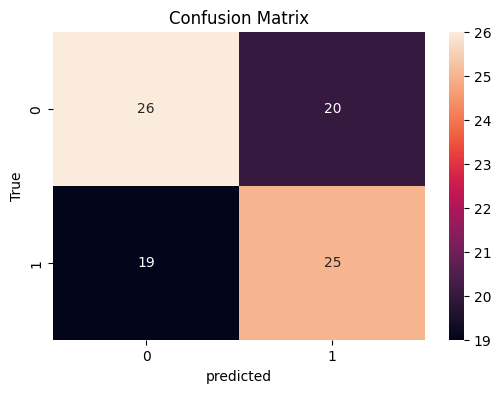

In [321]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### EditedNearestNeighbours

In [322]:
from imblearn.under_sampling import EditedNearestNeighbours

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
X_resampled_ens, y_resampled_ens = EditedNearestNeighbours().fit_resample(x, y)

y_resampled_ens.value_counts()

0    2836
1     180
Name: stroke, dtype: int64

### OneSidedSelection

In [323]:
from imblearn.under_sampling import OneSidedSelection

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_oss, y_resampled_oss = OneSidedSelection().fit_resample(x, y)

y_resampled_oss.value_counts()

0    3097
1     180
Name: stroke, dtype: int64

## 언더 샘플링 종류별 모델 성능 비교

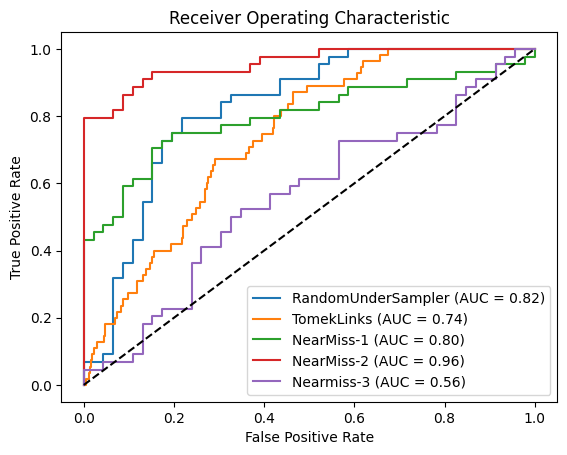

In [324]:
# RandomUnderSampler의 ROC curve
plt.plot(fpr_rus, tpr_rus, label='RandomUnderSampler (AUC = %0.2f)' % auc_rus)
# TomekLinks의 ROC curve
plt.plot(fpr_tm, tpr_tm, label='TomekLinks (AUC = %0.2f)' % auc_tm)
# Nearmiss-1의 ROC curve
plt.plot(fpr_ns1, tpr_ns1, label='NearMiss-1 (AUC = %0.2f)' % auc_ns1)
# Nearmiss-2의 ROC curve
plt.plot(fpr_ns2, tpr_ns2, label='NearMiss-2 (AUC = %0.2f)' % auc_ns2)
# Nearmiss-3의 ROC curve
plt.plot(fpr_ns3, tpr_ns3, label='Nearmiss-3 (AUC = %0.2f)' % auc_ns3)

# 기준선 그리기
plt.plot([0, 1], [0, 1], 'k--')

# 축과 범례 설정
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

# 그래프 출력
plt.show()

# 모델 선택

In [325]:
data = pd.read_csv("stroke final data.csv")

In [326]:
x = data.drop(['ever_married', 'Never_worked', 'children','stroke'],axis = 1) #독립변수
y = data["stroke"] # 종속변수

In [327]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)

## 로지스틱 회귀 모형

In [328]:
# 로지스틱 모델 초기화
model = LogisticRegression()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.69 precision :0.70 recall :0.64
MAE:0.31 
F1-score :0.67 


## 랜덤포레스트

In [329]:
random_forest = RandomForestClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=0)
random_forest.fit(x_train, y_train)

y_pred = random_forest.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.84 precision :0.85 recall :0.81
MAE:0.16 
F1-score :0.83 


## xgboost

In [330]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.90 precision :0.93 recall :0.86
MAE:0.10 
F1-score :0.89 


# feature importance

## feature importance

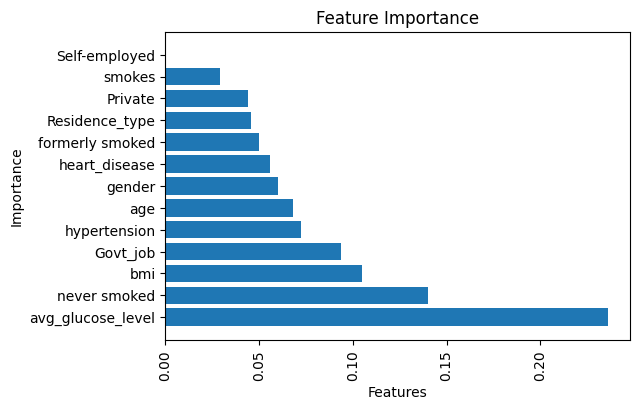

In [331]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## permutation importance

In [332]:
perm = PermutationImportance(xgb,random_state=42).fit(x_test, y_test)

# 시각화
eli5.show_weights(perm, feature_names=x_test.columns.tolist())

Weight,Feature
0.2578 ± 0.1422,avg_glucose_level
0.1044 ± 0.0387,bmi
0.0467 ± 0.0514,age
0.0178 ± 0.0301,gender
0.0178 ± 0.0227,heart_disease
0.0067 ± 0.0109,smokes
0.0044 ± 0.0178,Private
0.0044 ± 0.0227,never smoked
0.0044 ± 0.0109,hypertension
0.0022 ± 0.0166,formerly smoked


## weight

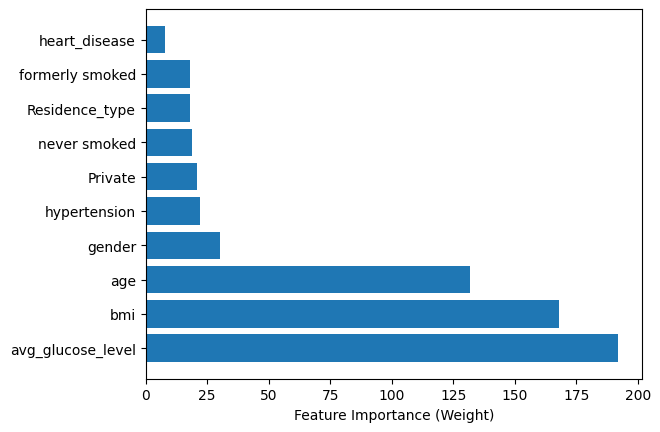

In [333]:
# Feature Importance 추출
importance_weight = xgb.get_booster().get_score(importance_type='weight')
sorted_importance_weight = sorted(importance_weight.items(), key=lambda x: x[1],reverse=True)

# 시각화
features, importance = zip(*sorted_importance_weight[:10])  # 상위 10개 feature
plt.barh(range(len(features)), importance, align='center')
plt.yticks(range(len(features)), features)
plt.xlabel('Feature Importance (Weight)')
plt.show()

## gain

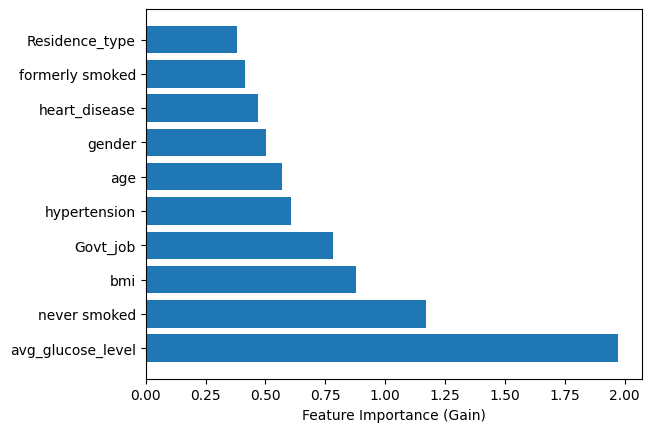

In [334]:
# Feature Importance 추출
importance_gain = xgb.get_booster().get_score(importance_type='gain')
sorted_importance_gain = sorted(importance_gain.items(), key=lambda x: x[1],reverse=True)

# 시각화
features, importance = zip(*sorted_importance_gain[:10])  # 상위 10개 feature
plt.barh(range(len(features)), importance, align='center')
plt.yticks(range(len(features)), features)
plt.xlabel('Feature Importance (Gain)')
plt.show()


## cover

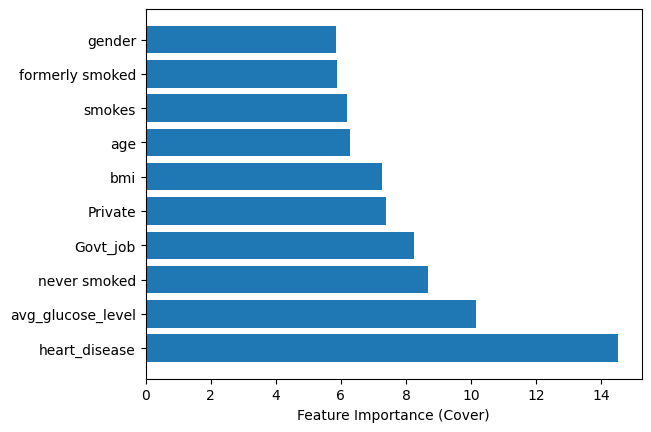

In [335]:
# Feature Importance 추출
importance_cover = xgb.get_booster().get_score(importance_type='cover')
sorted_importance_cover = sorted(importance_cover.items(), key=lambda x: x[1], reverse=True)

# 시각화
features, importance = zip(*sorted_importance_cover[:10])  # 상위 10개 feature
plt.barh(range(len(features)), importance, align='center')
plt.yticks(range(len(features)), features)
plt.xlabel('Feature Importance (Cover)')
plt.show()

- 5개 공통적으로 상위 5개에 속해 있던 변수 : avg_glucose_lever, bmi
- 4개 공통적으로 상위 5개 속해 있던 변수 : never_smoked
- 3개 공통적으로 상위 5개 : heart_disease
- 2개 공통적으로 상위 5개 : hypertension , age 

- 모델의 복잡성을 줄이기 위해 중요도 낮은 변수 제거 'ever_married', 'Never_worked', 'children'

# 최종 모델
* xgboost 모델에 feature selection 적용

In [336]:
x = df.drop(['stroke','ever_married', 'Never_worked', 'children'],axis = 1) # 중요도 낮은 변수 제거
y = df['stroke'] 

In [337]:
# NearMiss 2 언더샘플링
x_resampled_ns1, y_resampled_ns1 = NearMiss(version=1).fit_resample(x, y)

In [338]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.90 precision :0.93 recall :0.86
MAE:0.10 
F1-score :0.89 


In [339]:
# k-fold 교차검증 수행

k = 5  # 폴드 수
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증 수행 및 평가 지표 계산
scores = cross_validate(xgb, x_train, y_train, cv=k, scoring=scoring)

# 평균과 표준편차 계산
accuracy_mean = np.mean(scores['test_accuracy'])
precision_mean = np.mean(scores['test_precision'])
recall_mean = np.mean(scores['test_recall'])
f1_mean = np.mean(scores['test_f1'])

accuracy_std = np.std(scores['test_accuracy'])
precision_std = np.std(scores['test_precision'])
recall_std = np.std(scores['test_recall'])
f1_std = np.std(scores['test_f1'])

# 평가 지표와 표준편차 출력
print("Accuracy: {:.2f} (+/- {:.2f})".format(accuracy_mean, accuracy_std))
print("Precision: {:.2f} (+/- {:.2f})".format(precision_mean, precision_std))
print("Recall: {:.2f} (+/- {:.2f})".format(recall_mean, recall_std))
print("F1 score: {:.2f} (+/- {:.2f})".format(f1_mean, f1_std))

Accuracy: 0.86 (+/- 0.04)
Precision: 0.88 (+/- 0.10)
Recall: 0.85 (+/- 0.03)
F1 score: 0.86 (+/- 0.03)


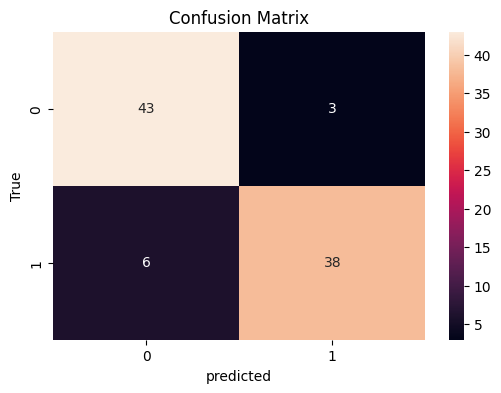

In [340]:
# 혼동행렬
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 추가 분석

In [341]:
not_normalized_data = pd.read_csv("not normalized dataset.csv")
not_normalized_data.drop(['Never_worked', 'children','ever_married'],axis=1,inplace=True)

## glucose level 126 이상(당뇨병) /  bmi 30 이상(비만) / 60세 이상(뇌졸중 위험군) 
* feature importance 분석 결과 공통적으로 상위에 위치했던 glucose level과 bmi
* 뇌졸중 환자 중 대부분의 비율을 차지하는 60대 이상

http://www.mohw.go.kr/react/al/sal0301vw.jsp?PAR_MENU_ID=04&MENU_ID=0403&page=26&CONT_SEQ=339009&SEARCHKEY=CONTENT&SEARCHVALUE=%EB%85%B8%EC%9D%B8


In [342]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30
subgroup_data1 = not_normalized_data[(not_normalized_data['age'] >= 60)
                                    & (not_normalized_data['avg_glucose_level'] >= glucose_threshold) 
                                    & (not_normalized_data['bmi'] >= bmi_threshold)].copy()

In [343]:
subgroup_data1 = subgroup_data1.drop(['age','avg_glucose_level','bmi'], axis=1)

In [344]:
x = subgroup_data1.drop('stroke', axis=1) # 독립변수
y = subgroup_data1['stroke'] # 종속변수
y.value_counts()

0    165
1     33
Name: stroke, dtype: int64

In [345]:
# 불균형 처리 
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    33
1    33
Name: stroke, dtype: int64

In [346]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.82 precision :0.86 recall :0.75
MAE:0.18 
F1-score :0.80 


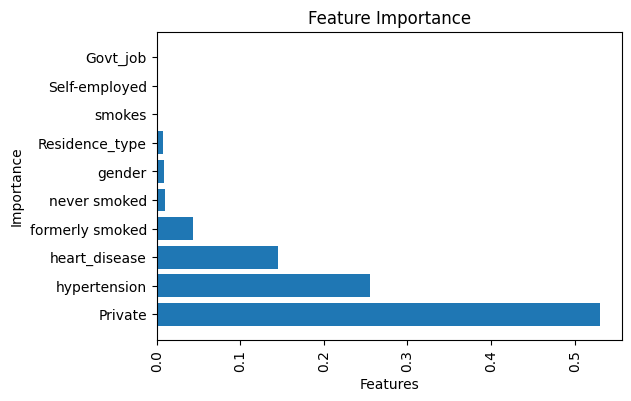

In [347]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## glucose level 126 이하(당뇨병X) / bmi 30 이상(비만) / 60세 이상

In [348]:
#Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data2 = not_normalized_data[(not_normalized_data['age'] >= 60)
                                     & (not_normalized_data['avg_glucose_level'] < glucose_threshold) 
                                     & (not_normalized_data['bmi'] >= bmi_threshold)].copy()
subgroup_data2 = subgroup_data2.drop(['age','avg_glucose_level','bmi'], axis=1)

In [349]:
x = subgroup_data2.drop('stroke', axis=1) # 독립변수
y = subgroup_data2['stroke'] # 종속변수
y.value_counts()

0    255
1     24
Name: stroke, dtype: int64

In [350]:
# 불균형 처리 
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    24
1    24
Name: stroke, dtype: int64

In [351]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.83 precision :1.00 recall :0.71
MAE:0.17 
F1-score :0.83 


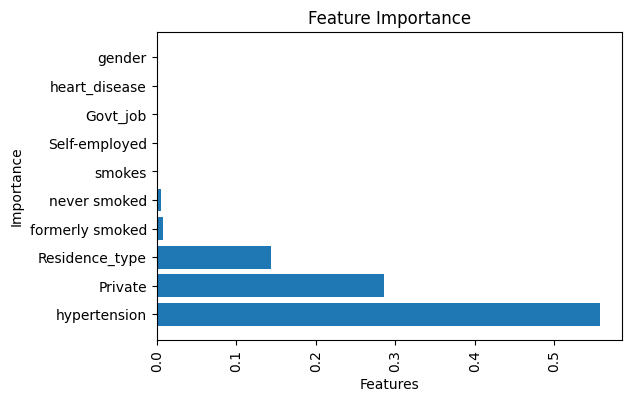

In [352]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## glucose level 126 이상(당뇨병)/ bmi 30 미만(비만X) / 60세 이상

In [353]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data3 = not_normalized_data[(not_normalized_data['age'] >= 60)
                                    & (not_normalized_data['avg_glucose_level'] >= glucose_threshold) 
                                    & (not_normalized_data['bmi'] < bmi_threshold)].copy()
subgroup_data3 = subgroup_data3.drop(['age','avg_glucose_level','bmi'], axis=1)


In [354]:
x = subgroup_data3.drop('stroke', axis=1) # 독립변수
y = subgroup_data3['stroke'] # 종속변수
y.value_counts()

0    108
1     30
Name: stroke, dtype: int64

In [355]:
# 불균형 처리 
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    30
1    30
Name: stroke, dtype: int64

In [356]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.67 precision :1.00 recall :0.50
MAE:0.33 
F1-score :0.67 


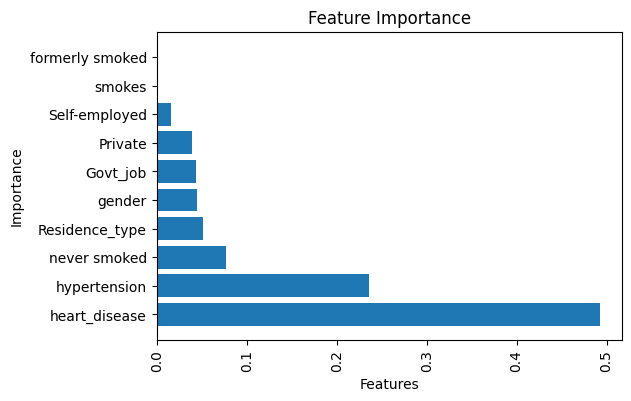

In [357]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## glucose level 126 미만(당뇨병X)/ bmi 30 미만(비만X) / 60세 이상

In [358]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data3 = not_normalized_data[(not_normalized_data['age'] >= 60)
                                    & (not_normalized_data['avg_glucose_level'] < glucose_threshold) 
                                    & (not_normalized_data['bmi'] < bmi_threshold)].copy()
subgroup_data3 = subgroup_data3.drop(['age','avg_glucose_level','bmi'], axis=1)


In [359]:
x = subgroup_data3.drop('stroke', axis=1) # 독립변수
y = subgroup_data3['stroke'] # 종속변수
y.value_counts()

0    394
1     45
Name: stroke, dtype: int64

In [360]:
# 불균형 처리 
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    45
1    45
Name: stroke, dtype: int64

In [361]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :1.00 precision :1.00 recall :1.00
MAE:0.00 
F1-score :1.00 


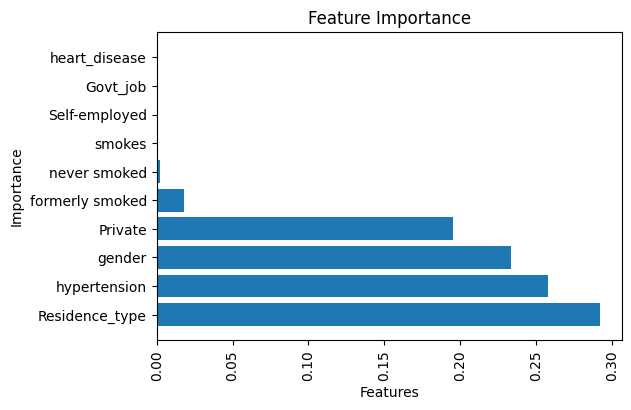

In [362]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## 70대
* EDA 결과 70대에서 가장 많은 뇌졸중 환자 수를 보임

In [363]:
data_age_70 = pd.read_csv("data_age_70.csv")
age70_index = data_age_70["index"]
data_70s = data.iloc[age70_index]

In [364]:
x_70s = data_70s.drop(['Never_worked', 'children','ever_married','stroke'],axis=1) #독립변수
y_70s = data_70s["stroke"] # 종속변수
y.value_counts()

0    394
1     45
Name: stroke, dtype: int64

In [365]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x_70s, y_70s)
y_resampled_ns2.value_counts()

0    63
1    63
Name: stroke, dtype: int64

In [366]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.66 precision :0.62 recall :0.57
MAE:0.34 
F1-score :0.59 


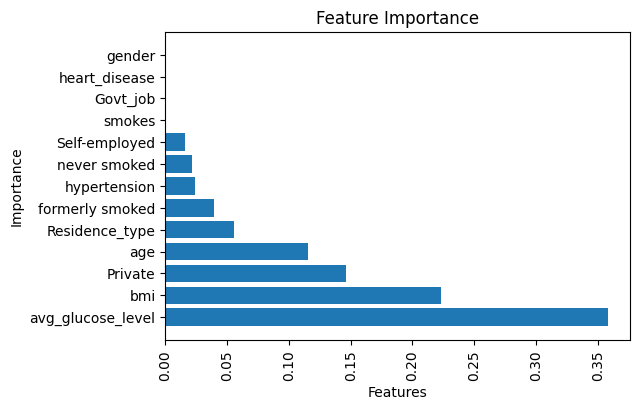

In [367]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

## 중요변수 제거(bmi, avg_glucose_level )

In [368]:
data_drop_importance = data.drop(["bmi","avg_glucose_level"],axis=1)

In [369]:
x = data_drop_importance.drop(['Never_worked', 'children','ever_married','stroke'],axis=1) #독립변수
y = data_drop_importance["stroke"] # 종속변수
y.value_counts()

0    3242
1     180
Name: stroke, dtype: int64

In [370]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [371]:
xgb = XGBClassifier()

x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.25, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy :{:.2f}".format(accuracy),"precision :{:.2f}".format(precision),"recall :{:.2f}".format(recall))
print("MAE:{:.2f} ".format(mae))
print("F1-score :{:.2f} ".format(f1))

accuracy :0.89 precision :0.93 recall :0.84
MAE:0.11 
F1-score :0.88 


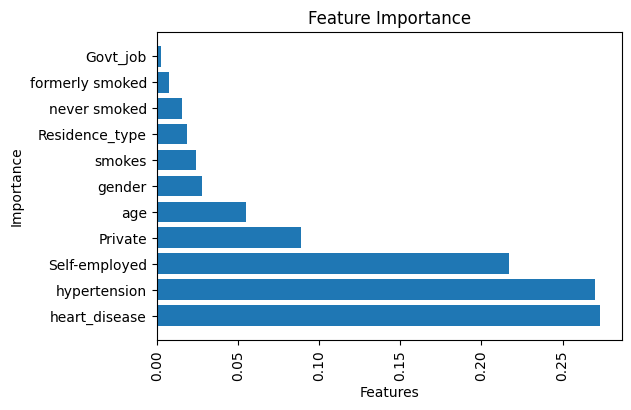

In [372]:
# Feature Importance 추출
importance = xgb.feature_importances_
features = x_train.columns

# 정렬된 인덱스 가져오기
sorted_idx = np.argsort(importance)[::-1]

# 정렬된 Feature Importance 및 Feature 이름
importance_sorted = importance[sorted_idx]
features_sorted = [features[i] for i in sorted_idx]

# 시각화
plt.figure(figsize=(6, 4))
plt.barh(range(len(importance_sorted)), importance_sorted, tick_label=features_sorted)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

- 조건을 넣으면서 데이터 수가 굉장히 적어짐 일반화 하긴 힘들 수 있음 / 성능평가도 필요 없을 듯 데이터 수가 적어서 
- but feature importance 자체는 해석 할순 있음 -> 일반화 할순 없겠지만